In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path = Path("/Users/darina/Desktop/MODO")

file_2025 = base_path / "prices 2025.xlsx"
file_2026 = base_path / "prices 2026.xlsx"

In [2]:
def load_workbook_all_sheets(file_path):
    xls = pd.ExcelFile(file_path)
    monthly_dfs = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        df["source_sheet"] = sheet
        monthly_dfs.append(df)

    combined = pd.concat(monthly_dfs, ignore_index=True)
    return combined

df_2025 = load_workbook_all_sheets(file_2025)
df_2026 = load_workbook_all_sheets(file_2026)

df = pd.concat([df_2025, df_2026], ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (967012, 8)


/var/folders/zw/lnm3gcv911z6dttbzww5qsj00000gn/T/ipykernel_18563/2955284247.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(monthly_dfs, ignore_index=True)


,Delivery Date,Delivery Hour,Delivery Interval,Repeated Hour Flag,Settlement Point Name,Settlement Point Type,Settlement Point Price,source_sheet
0,01/01/2025,1,1,N,HB_BUSAVG,SH,17.90,Jan
1,01/01/2025,1,2,N,HB_BUSAVG,SH,17.98,Jan
2,01/01/2025,1,3,N,HB_BUSAVG,SH,18.21,Jan
3,01/01/2025,1,4,N,HB_BUSAVG,SH,18.22,Jan
4,01/01/2025,1,1,N,HB_HOUSTON,HU,17.90,Jan


In [3]:
print(df.columns.tolist())


['Delivery Date', 'Delivery Hour', 'Delivery Interval', 'Repeated Hour Flag', 'Settlement Point Name', 'Settlement Point Type', 'Settlement Point Price', 'source_sheet']


In [4]:
df = df[df["Settlement Point Name"] == "HB_HOUSTON"].copy()
print("After filtering:", df.shape)

After filtering: (42044, 8)


In [5]:
df["Delivery Date"] = pd.to_datetime(df["Delivery Date"])
df["Delivery Hour"] = pd.to_numeric(df["Delivery Hour"], errors="coerce")
df["Delivery Interval"] = pd.to_numeric(df["Delivery Interval"], errors="coerce")
df["Settlement Point Price"] = pd.to_numeric(df["Settlement Point Price"], errors="coerce")

In [6]:
df["hour_start"] = df["Delivery Hour"] - 1
df["minute_start"] = (df["Delivery Interval"] - 1) * 15

df["timestamp"] = (
    df["Delivery Date"]
    + pd.to_timedelta(df["hour_start"], unit="h")
    + pd.to_timedelta(df["minute_start"], unit="m")
)

df = df.sort_values("timestamp").reset_index(drop=True)

In [7]:
df = df[["timestamp", "Settlement Point Price"]].copy()

df = df.rename(columns={
    "Settlement Point Price": "price"
})

df.head()

,timestamp,price
0,2025-01-01 00:00:00,17.90
1,2025-01-01 00:15:00,17.98
2,2025-01-01 00:30:00,18.21
3,2025-01-01 00:45:00,18.22
4,2025-01-01 01:00:00,17.97


In [8]:
df = df.dropna(subset=["price"])

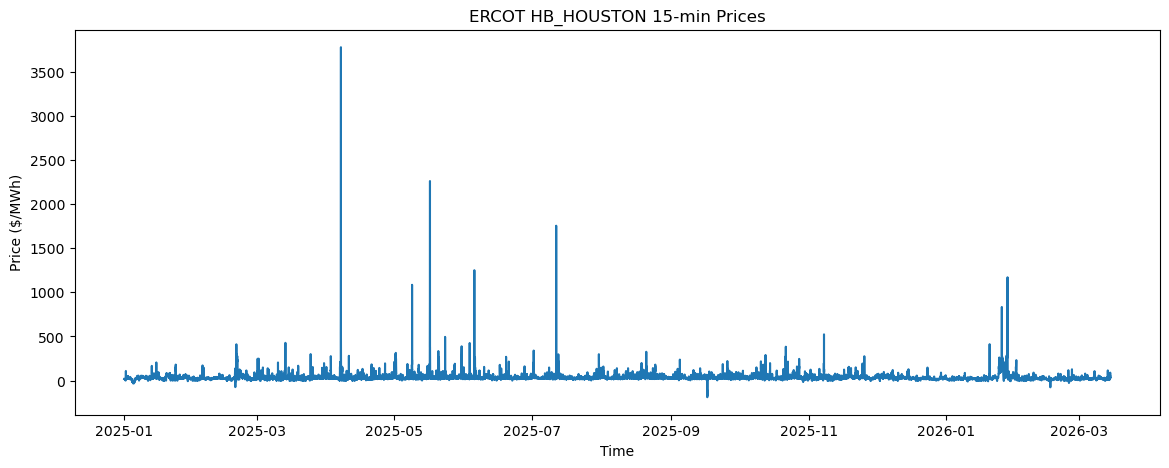

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["price"])
plt.title("ERCOT HB_HOUSTON 15-min Prices")
plt.xlabel("Time")
plt.ylabel("Price ($/MWh)")
plt.show()

/var/folders/zw/lnm3gcv911z6dttbzww5qsj00000gn/T/ipykernel_18563/64427957.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


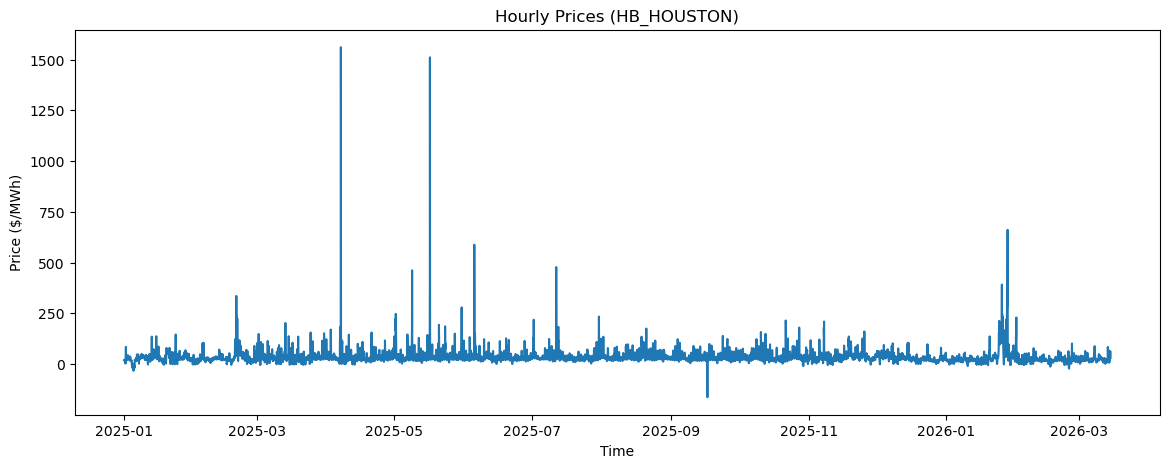

In [12]:
hourly_df = (
    df.set_index("timestamp")
      .resample("H")
      .mean()
      .reset_index()
)
hourly_df["date"] = hourly_df["timestamp"].dt.date
hourly_df["hour"] = hourly_df["timestamp"].dt.hour

hourly_df.head()
plt.figure(figsize=(14, 5))
plt.plot(hourly_df["timestamp"], hourly_df["price"])
plt.title("Hourly Prices (HB_HOUSTON)")
plt.xlabel("Time")
plt.ylabel("Price ($/MWh)")
plt.show()


In [13]:
POWER_MW = 100
ENERGY_MWH = 400
EFFICIENCY = 0.9

DURATION_HOURS = int(ENERGY_MWH / POWER_MW)

print("Battery duration:", DURATION_HOURS, "hours")

Battery duration: 4 hours


In [14]:
results = []

for day, group in hourly_df.groupby("date"):
    
    group = group.sort_values("price")
    
    charge_hours = group.head(DURATION_HOURS)
    discharge_hours = group.tail(DURATION_HOURS)
    
    charge_cost = (charge_hours["price"] * POWER_MW).sum()
    discharge_revenue = (discharge_hours["price"] * POWER_MW * EFFICIENCY).sum()
    
    profit = discharge_revenue - charge_cost
    
    results.append({
        "date": day,
        "daily_profit": profit
    })

results_df = pd.DataFrame(results)
results_df.head()

,date,daily_profit
0,2025-01-01,19356.325
1,2025-01-02,6923.775
2,2025-01-03,4245.975
3,2025-01-04,14381.975
4,2025-01-05,19590.100


In [15]:
print("Total Profit:", results_df["daily_profit"].sum())
print("Average Daily Profit:", results_df["daily_profit"].mean())

Total Profit: 7430948.15
Average Daily Profit: 16965.6350456621


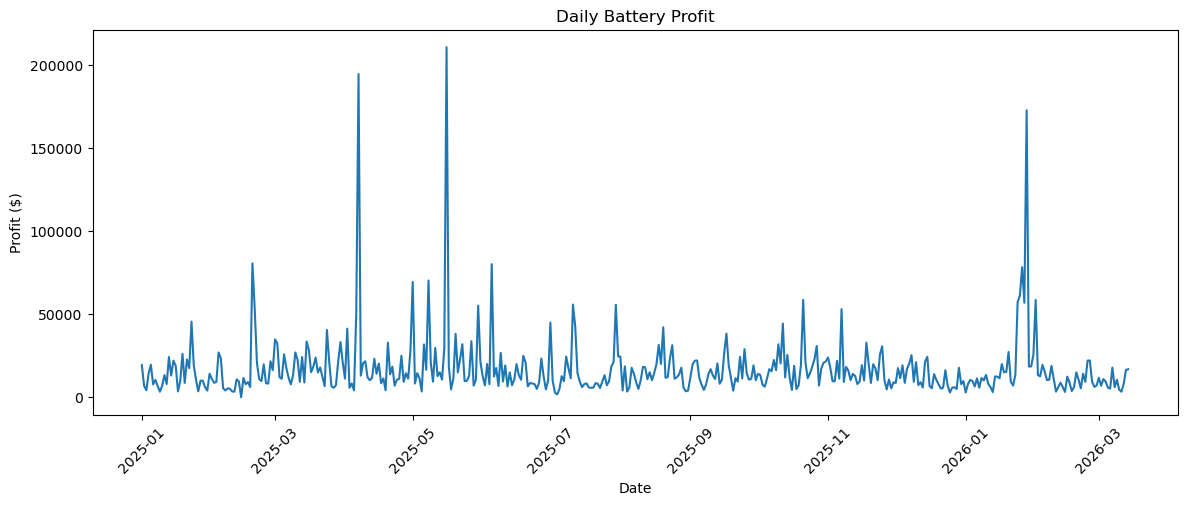

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(results_df["date"], results_df["daily_profit"])
plt.title("Daily Battery Profit")
plt.xlabel("Date")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.show()